# INI

In [2]:
# pip install MetaTrader5 pandas

# Initialization test

In [1]:
import MetaTrader5 as mt5
import pandas as pd

# 1. 初始化并连接 MT5 终端
if not mt5.initialize():
    print("MT5 初始化失败，错误码 =", mt5.last_error())
    quit()

print("MT5 连接成功！")

MT5 连接成功！


In [3]:
# 2. 设置数据拉取参数
# 注意：务必检查你 MT5 左侧“市场报价”里的黄金名称。
# 有些券商是 "XAUUSD"，有些会有后缀如 "XAUUSD.m" 或 "GOLD"
symbol = "XAUUSD" 
timeframe = mt5.TIMEFRAME_M15  # 选择 15分钟 K线，你可以随时改成 _H1 或 _D1
num_bars = 1000                # 向前拉取最近的 1000 根 K线

# 3. 从当前时间向前拉取数据
print(f"正在拉取 {symbol} 的历史数据...")
rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, num_bars)

# 4. 获取数据后，安全断开与 MT5 的连接 (保持良好习惯，释放内存)
mt5.shutdown()

# 5. 数据清洗与格式化
if rates is None:
    print(f"未能获取数据。请检查：\n1. MT5 是否已登录。\n2. 品种名称 '{symbol}' 是否与券商完全一致。")
else:
    # 将获取的 tuple 结构转换为 Pandas DataFrame
    df = pd.DataFrame(rates)
    
    # MT5 的时间戳是秒级别的 Unix 时间，需要转换为可读时间
    df['time'] = pd.to_datetime(df['time'], unit='s')
    
    # 按照回测框架的惯例，提取有用的列：时间、开盘、最高、最低、收盘、成交量
    df = df[['time', 'open', 'high', 'low', 'close', 'tick_volume']]
    
    # 将 'time' 列设置为索引
    df.set_index('time', inplace=True)
    
    print(f"\n成功获取 {symbol} K线数据，共 {len(df)} 条。")
    print("============== 数据预览 ==============")
    print(df.head())

正在拉取 XAUUSD 的历史数据...

成功获取 XAUUSD K线数据，共 1000 条。
============== 数据预览 ==============
                        open     high      low    close  tick_volume
time                                                                
2026-03-18 22:00:00  4843.06  4848.55  4823.70  4825.80         4319
2026-03-18 22:15:00  4825.80  4828.33  4808.85  4811.30         4890
2026-03-18 22:30:00  4811.30  4821.39  4806.64  4820.89         4525
2026-03-18 22:45:00  4820.91  4826.67  4816.23  4817.91         2929
2026-03-19 00:00:00  4829.37  4837.13  4815.94  4818.74         2311


In [11]:
# pip install backtrader matplotlib

In [17]:
import MetaTrader5 as mt5
import pandas as pd
import backtrader as bt
import datetime
%matplotlib inline

# ==========================================
# 1. 数据获取模块 (复用并封装了你刚才跑通的代码)
# ==========================================
def get_mt5_data(symbol="XAUUSD", timeframe=mt5.TIMEFRAME_M15, num_bars=1000):
    if not mt5.initialize():
        print("MT5 初始化失败")
        return None
        
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, num_bars)
    mt5.shutdown()
    
    if rates is None:
        return None
        
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df = df[['time', 'open', 'high', 'low', 'close', 'tick_volume']]
    df.rename(columns={'tick_volume': 'volume'}, inplace=True) # Backtrader 默认识别 volume 列
    df.set_index('time', inplace=True)
    return df

# ==========================================
# 2. 策略定义模块 (你的交易逻辑将写在这里)
# ==========================================
class SmaCrossStrategy(bt.Strategy):
    # 定义策略参数，方便后期优化。这里默认快线10，慢线30
    params = dict(
        fast_period=10,
        slow_period=30
    )

    def __init__(self):
        # 初始化指标：计算两根简单移动均线 (SMA)
        self.sma_fast = bt.ind.SMA(period=self.p.fast_period)
        self.sma_slow = bt.ind.SMA(period=self.p.slow_period)
        
        # 内置交叉信号：1表示金叉(快穿慢)，-1表示死叉(慢穿快)
        self.crossover = bt.ind.CrossOver(self.sma_fast, self.sma_slow)

    def next(self):
        # next() 方法会在每一根 K 线产出时被调用一次
        
        # 如果当前没有持仓
        if not self.position:
            # 发生金叉，买入做多
            if self.crossover > 0:
                print(f"{self.data.datetime.date(0)}: 触发买入信号，价格 {self.data.close[0]}")
                self.buy() 
                
        # 如果当前已经持仓
        elif self.crossover < 0:
            # 发生死叉，平仓
            print(f"{self.data.datetime.date(0)}: 触发平仓信号，价格 {self.data.close[0]}")
            self.close()



In [ ]:
# ==========================================
# 3. 回测引擎驱动模块 (Cerebro)
# ==========================================

# 1. 拉取数据
print("正在从 MT5 拉取 XAUUSD 数据...")
df = get_mt5_data(symbol="XAUUSD", timeframe=mt5.TIMEFRAME_M15, num_bars=2000)

if df is not None:
    # 2. 初始化 Cerebro 引擎
    cerebro = bt.Cerebro()
    
    # 3. 将 Pandas 数据转换为 Backtrader 可识别的数据流
    data = bt.feeds.PandasData(dataname=df)
    cerebro.adddata(data)
    
    # 4. 添加我们上面写的策略
    cerebro.addstrategy(SmaCrossStrategy)
    
    # 5. 设置初始资金：10000 美金
    cerebro.broker.setcash(10000.0)
    
    # （可选）设置每次交易量，这里简化为每次买1标准手
    cerebro.addsizer(bt.sizers.FixedSize, stake=1)
    
    print(f"回测开始，初始资金: {cerebro.broker.getvalue():.2f}")
    
    # 6. 运行回测
    cerebro.run()
    
    print(f"回测结束，最终资金: {cerebro.broker.getvalue():.2f}")
    
    # 7. 绘制可视化图表
    print("正在生成图表...")
    # style='candlestick' 会将图表画成 K线图
    cerebro.plot(style='candlestick', barup='green', bardown='red')

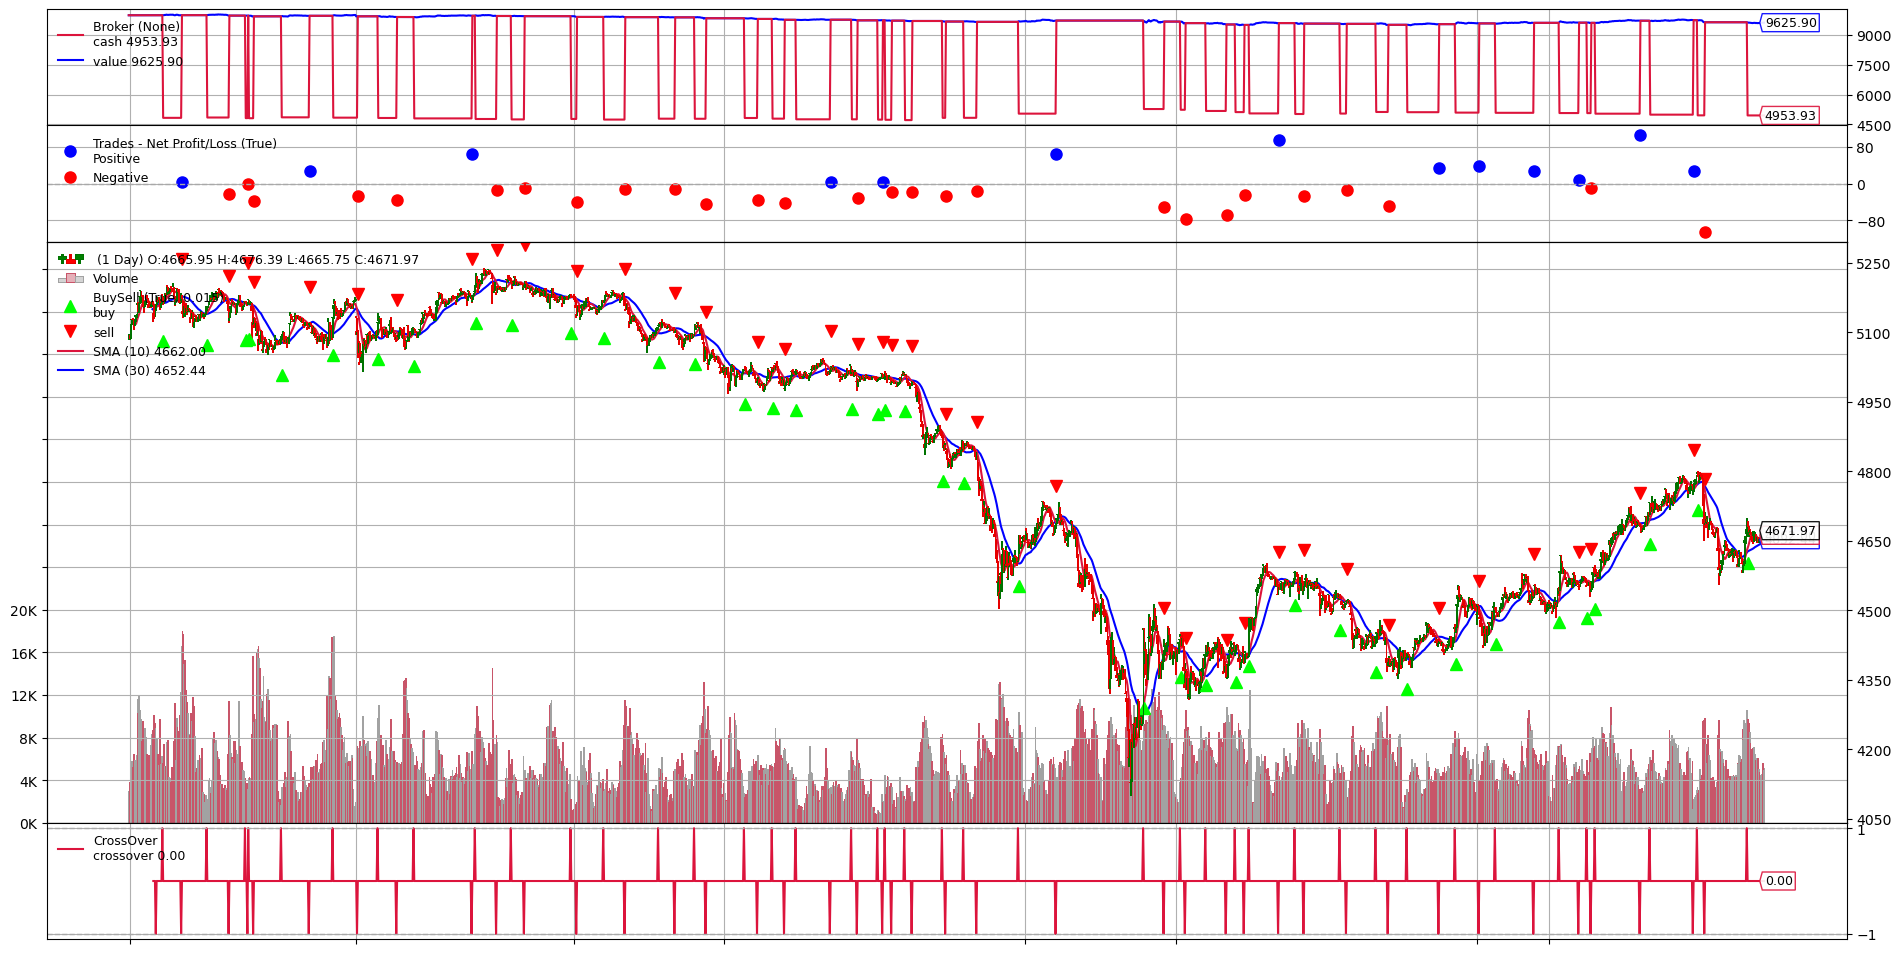

In [20]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10] # 15是宽度，8是高度，你可以根据屏幕自己调
figs = cerebro.plot(iplot=False, style='candlestick', barup='green', bardown='red')

# Test v.1

In [22]:
%load_ext autoreload
%autoreload 2
from my_utils import BaseEvalStrategy, run_evaluation, plot_single_day_data, plot_single_day_with_trades
import MetaTrader5 as mt5
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# 这是一个测试策略，继承了我们的基类
class MyTestStrategy(BaseEvalStrategy):
    def next(self):
        super().next() # 必须调用父类的方法来记录每日最低净值
        
        # 时间过滤：如果不在你设定的 0800 到 2000 之间，坚决不开仓
        if not self.is_in_trading_window():
            return
            
        # 极简测试逻辑：为了测试框架，每逢周一买入，盈利5块或亏损3块平仓...
        # 你的均线+价格真实逻辑将写在这里！
        if not self.position:
            if self.data.datetime.date(0).weekday() == 0: 
                self.buy()
        else:
            buy_price = self.position.price
            if self.data.close[0] > buy_price + 5 or self.data.close[0] < buy_price - 3:
                self.close()

# 启动引擎！
results = run_evaluation(
    start_date='20260101',
    end_date='20260331',
    daily_start='0800',
    daily_end='2000',
    symbols=['XAUUSD'],
    strategy_class=MyTestStrategy
)

# 打印评测报告
print("\n--- 全局评估 ---")
for k, v in results['global_metrics'].items():
    print(f"{k}: {v}")

print("\n--- 交易明细表前 5 行 ---")
if results['trade_details'] is not None:
    print(results['trade_details'].head())

print("\n--- 每日统计表前 5 行 ---")
if results['daily_summary'] is not None:
    print(results['daily_summary'].head())
    
# 如果某天你想画图，执行：
# results['plot_data'].plot(iplot=False, style='candlestick', figsize=(15,8))

开始评测区间: 20260101 -> 20260331 | 交易时段: 0800-2000
评测完成！

--- 全局评估 ---
Initial Capital: 10000.0
Final Capital: 9511.556303999992
Total Net PnL: -488.4436960000063
Max Drawdown (%): 6.959572944938293
Win Rate (%): 47.11111111111111
Sharpe Ratio: -0.24516761955985739
Total Trades: 225

--- 交易明细表前 5 行 ---
        open_datetime      close_datetime  symbol  ...    pnl   pnl_comm  close_date
0 2026-01-05 08:15:00 2026-01-05 08:30:00  XAUUSD  ...   5.68   4.795760  2026-01-05
1 2026-01-05 08:45:00 2026-01-05 10:30:00  XAUUSD  ...   6.30   5.415316  2026-01-05
2 2026-01-05 10:45:00 2026-01-05 11:45:00  XAUUSD  ...   7.57   6.683231  2026-01-05
3 2026-01-05 12:00:00 2026-01-05 13:30:00  XAUUSD  ... -17.65 -18.535205  2026-01-05
4 2026-01-05 13:45:00 2026-01-05 14:00:00  XAUUSD  ...  -4.76  -5.644342  2026-01-05

[5 rows x 10 columns]

--- 每日统计表前 5 行 ---
            total_trades  win_trades  ...  max_single_loss     min_value
close_date                            ...                               
2

正在准备绘制 20260105 的图表...
成功获取 XAUUSD 20260105 数据，共 61 条。正在绘图...


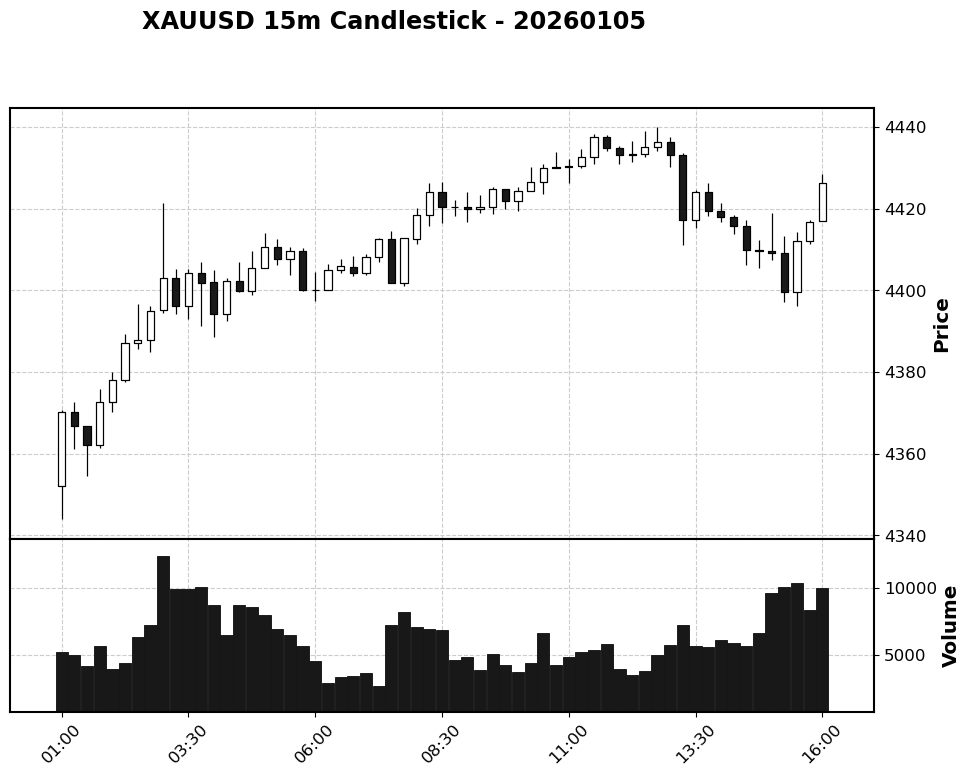

In [ ]:
# results['plot_data'].plot(iplot=False, style='candlestick', figsize=(15,8))
target_date = '20260105' # 替换为你想要查看的特定日期
print(f"正在准备绘制 {target_date} 的图表...")

# 调用函数
# 注意：确保这里引用的品种名称与 MT5 一致
# timeframe 使用 MT5 格式，如 mt5.TIMEFRAME_M15
plot_single_day_data("XAUUSD", mt5.TIMEFRAME_M15, target_date)

准备绘制 20260105 的图表，找到 2 个交易动作信号...


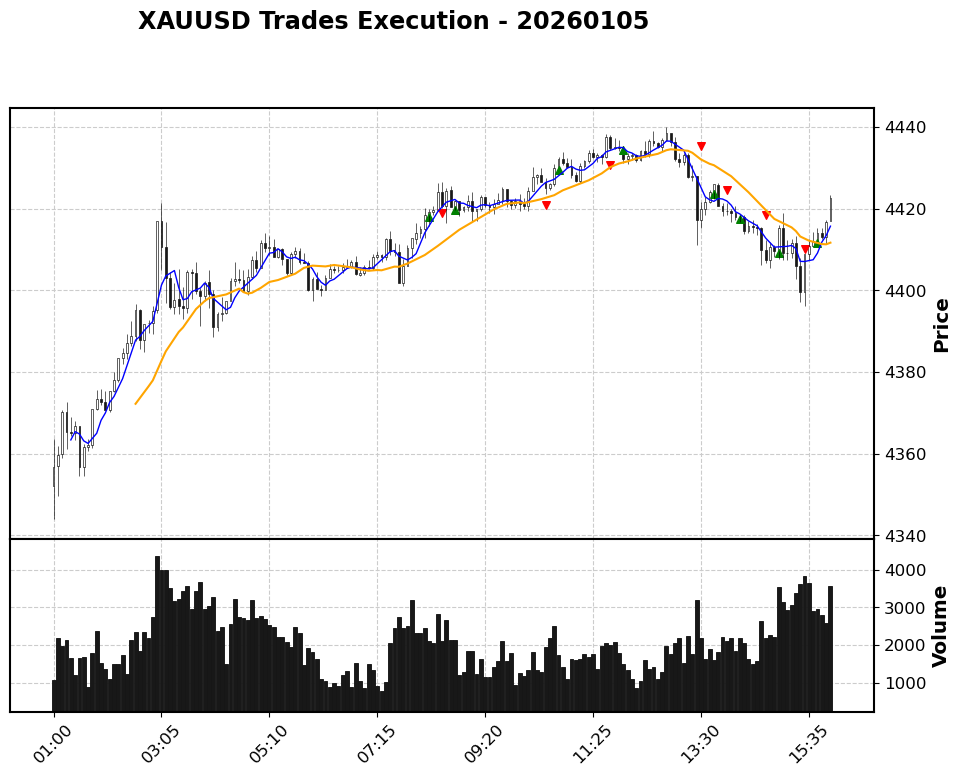

In [24]:
# 假设你想看 2026年3月15日 的具体开平仓情况
target_date = '20260105' 

plot_single_day_with_trades(
    symbol="XAUUSD", 
    timeframe=mt5.TIMEFRAME_M5, 
    plot_date_str=target_date, 
    trade_details=results['trade_details'] # 把评测框架吐出来的明细表塞进去！
)

# END